In [ ]:

!git clone --depth 1 https://github.com/vkola-lab/ncomms2022.git
%cd ncomms2022

Cloning into 'ncomms2022'...
remote: Enumerating objects: 2998, done.
remote: Counting objects: 100% (2998/2998), done.
remote: Compressing objects: 100% (2216/2216), done.
remote: Total 2998 (delta 724), reused 2994 (delta 724), pack-reused 0 (from 0)
Receiving objects: 100% (2998/2998), 284.40 MiB | 228.00 KiB/s, done.
Resolving deltas: 100% (724/724), done.
You can inspect what was checked out with 'git status'
and retry with 'git restore --source=HEAD :/'

^C
/content/ncomms2022


In [ ]:

!pip install torch>=1.10
!pip install numpy>=1.19
!pip install tqdm>=4.31
!pip install nibabel>=3.2
!pip install matplotlib>=3.3
!pip install scikit-learn>=0.23
!pip install scipy>=1.5.4
!pip install shap>=0.37
!pip install xgboost>=1.3.3
!pip install catboost>=0.24

In [ ]:

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
import fileinput
import sys

with open('demo_inference.py', 'r') as f:
    content = f.read()
if torch.cuda.is_available():
    content = content.replace('device=1', 'device=0')
else:
    content = content.replace('device=1', 'device=-1')  # -1 = CPU

with open('demo_inference.py', 'w') as f:
    f.write(content)

CUDA available: True
Number of GPUs: 1
File đã được sửa!


In [ ]:

with open('model_wrappers.py', 'r') as f:
    content = f.read()

old_code = '''    def load_MLP_weights(self):
        for i in range(len(self.tasks)):
            target_file = os.path.join(self.checkpoint_dir, self.tasks[i]+'_'+str(self.epochs)+'.pth')
            print('loading ', target_file)
            try:
                self.MLPs[i].load_state_dict(torch.load(target_file))
            except:
                self.MLPs[i].load_state_dict(remove_module(torch.load(target_file)))'''

new_code = '''    def load_MLP_weights(self):
        for i in range(len(self.tasks)):
            target_file = os.path.join(self.checkpoint_dir, self.tasks[i]+'_'+str(self.epochs)+'.pth')
            print('loading ', target_file)
            # Map to current device
            map_location = f'cuda:{self.device}' if self.device >= 0 else 'cpu'
            try:
                self.MLPs[i].load_state_dict(torch.load(target_file, map_location=map_location))
            except:
                self.MLPs[i].load_state_dict(remove_module(torch.load(target_file, map_location=map_location)))'''

content = content.replace(old_code, new_code)

# Tương tự với load_backbone_weights
old_backbone = '''    def load_backbone_weights(self):
        target_file = os.path.join(self.checkpoint_dir, 'backbone'+'_'+str(self.epochs)+'.pth')
        print('loading ', target_file)
        try:
            self.backbone.load_state_dict(torch.load(target_file))
        except:
            self.backbone.load_state_dict(remove_module(torch.load(target_file)))'''

new_backbone = '''    def load_backbone_weights(self):
        target_file = os.path.join(self.checkpoint_dir, 'backbone'+'_'+str(self.epochs)+'.pth')
        print('loading ', target_file)
        # Map to current device
        map_location = f'cuda:{self.device}' if self.device >= 0 else 'cpu'
        try:
            self.backbone.load_state_dict(torch.load(target_file, map_location=map_location))
        except:
            self.backbone.load_state_dict(remove_module(torch.load(target_file, map_location=map_location)))'''

content = content.replace(old_backbone, new_backbone)

with open('model_wrappers.py', 'w') as f:
    f.write(content)


✓ File model_wrappers.py đã được sửa!


In [ ]:

with open('model_wrappers.py', 'r') as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    if 'torch.load(target_file)' in line and 'map_location' not in line:
        new_line = line.replace(
            'torch.load(target_file)',
            'torch.load(target_file, map_location=f"cuda:{self.device}" if self.device >= 0 else "cpu")'
        )
        new_lines.append(new_line)
    else:
        new_lines.append(line)
with open('model_wrappers.py', 'w') as f:
    f.writelines(new_lines)
!grep -n "map_location" model_wrappers.py | head -5

✓ Đã sửa file model_wrappers.py
433:        weights = torch.load(target_file, map_location=lambda storage, loc: storage.cuda(self.device))
444:                self.MLPs[i].load_state_dict(torch.load(target_file, map_location=f"cuda:{self.device}" if self.device >= 0 else "cpu"))
446:                self.MLPs[i].load_state_dict(remove_module(torch.load(target_file, map_location=f"cuda:{self.device}" if self.device >= 0 else "cpu")))


In [ ]:
!python demo_inference.py

2026-01-07 01:25:50.092337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767749150.111271    3963 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767749150.117370    3963 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767749150.131717    3963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767749150.131745    3963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767749150.131749    3963 computation_placer.cc:177] computation placer alr

In [ ]:
import pandas as pd

results = pd.read_csv('/content/ncomms2022/demo/demo.csv')

print(" Kết quả dự đoán:\n")
print(results.to_string())
print(f"\nTổng số: {len(results)} MRI scans đã được phân tích")
print(f"\nCác cột dữ liệu: {list(results.columns)}")

📋 Kết quả dự đoán:

    filename         path  ADD  COG
0  demo1.npy  ./demo/mri/  1.0    2
1  demo2.npy  ./demo/mri/  1.0    2
2  demo3.npy  ./demo/mri/  NaN    1

📊 Tổng số: 3 MRI scans đã được phân tích

📁 Các cột dữ liệu: ['filename', 'path', 'ADD', 'COG']


In [ ]:

if len(results) > 0:
    print("\n Chi tiết dự đoán cho từng bệnh nhân:")
    for idx, row in results.iterrows():
        print("\n--- MRI Scan #{idx+1} ---")
        print("Patient ID: {row.get('RID', 'N/A')}")
        print("ADD Prediction: {row.get('ADD_pred', 'N/A')}")
        print("COG Prediction: {row.get('COG_pred', 'N/A'):.2f}")


🔍 Chi tiết dự đoán cho từng bệnh nhân:

--- MRI Scan #{idx+1} ---
Patient ID: {row.get('RID', 'N/A')}
ADD Prediction: {row.get('ADD_pred', 'N/A')}
COG Prediction: {row.get('COG_pred', 'N/A'):.2f}

--- MRI Scan #{idx+1} ---
Patient ID: {row.get('RID', 'N/A')}
ADD Prediction: {row.get('ADD_pred', 'N/A')}
COG Prediction: {row.get('COG_pred', 'N/A'):.2f}

--- MRI Scan #{idx+1} ---
Patient ID: {row.get('RID', 'N/A')}
ADD Prediction: {row.get('ADD_pred', 'N/A')}
COG Prediction: {row.get('COG_pred', 'N/A'):.2f}


In [ ]:
import pandas as pd
import numpy as np

results = pd.read_csv('/content/ncomms2022/demo/demo.csv')

print("="*60)
print("PHÂN TÍCH KẾT QUẢ DỰ ĐOÁN BỆNH ALZHEIMER")
print("="*60)

ADD_labels = {
    0: "NC - Normal Cognition (Nhận thức bình thường)",
    1: "MCI - Mild Cognitive Impairment (Suy giảm nhận thức nhẹ)",
    2: "AD - Alzheimer's Disease (Bệnh Alzheimer)",
    3: "nADD - Non-AD Dementia (Sa sút trí tuệ không phải Alzheimer)"
}

COG_labels = {
    0: "Severe cognitive impairment (Suy giảm nhận thức nặng)",
    1: "Moderate cognitive impairment (Suy giảm nhận thức trung bình)",
    2: "Mild cognitive impairment (Suy giảm nhận thức nhẹ)",
    3: "Normal cognition (Nhận thức bình thường)"
}

print("\nKẾT QUẢ TỪNG BỆNH NHÂN:\n")

for idx, row in results.iterrows():
    print(f"{'─'*58}┐")
    print(f"{'MRI SCAN #' + str(idx+1):^56} ")
    print(f"{'─'*58}┤")
    print(f"Filename: {row['filename']:<45} ")

    # Phân tích ADD
    if pd.notna(row['ADD']):
        add_class = int(row['ADD'])
        print(f" {'':58} ")
        print(f"  CHẨN ĐOÁN ALZHEIMER:       ")
        print(f"   → {ADD_labels[add_class]:<50}")

        if add_class == 0:
            status = " KHỎE MẠNH"
        elif add_class == 1:
            status = "CẦN THEO DÕI"
        elif add_class == 2:
            status = " CẦN ĐIỀU TRỊ"
        else:
            status = " SA SÚT TRÍ TUỆ KHÁC"
        print(f"Trạng thái: {color} {status:<39}")
    else:
        print(f" CHẨN ĐOÁN ALZHEIMER: Không xác định được ")

    # Phân tích COG
    if pd.notna(row['COG']):
        cog_score = int(row['COG'])
        print(f" {'':58} ")
        print(f" ĐÁNH GIÁ NHẬN THỨC:   ")
        print(f" {COG_labels[cog_score]:<50}")
        print(f"Điểm số: {cog_score}/3 { cog_score}{ (3-cog_score):<40} ")

    print(f"└{'─'*58}┘\n")

# Thống kê tổng quan
print("\n" + "="*60)
print("THỐNG KÊ TỔNG QUAN")
print("="*60)

# ADD statistics
add_counts = results['ADD'].value_counts().sort_index()
print("\n Phân bố chẩn đoán Alzheimer:")
for label, count in add_counts.items():
    if pd.notna(label):
        pct = (count / len(results)) * 100
        print(f"   {ADD_labels[int(label)]}")
        print(f"    {int(count)} ca ({pct:.1f}%) { int(pct/5)}")

# COG statistics
print("\n Phân bố mức độ nhận thức:")
cog_counts = results['COG'].value_counts().sort_index()
for score, count in cog_counts.items():
    if pd.notna(score):
        pct = (count / len(results)) * 100
        print(f"   Level {int(score)}: {COG_labels[int(score)]}")
        print(f"    {int(count)} ca ({pct:.1f}%) { int(pct/5)}")

print("\n" + "="*60)

PHÂN TÍCH KẾT QUẢ DỰ ĐOÁN BỆNH ALZHEIMER

KẾT QUẢ TỪNG BỆNH NHÂN:

┌──────────────────────────────────────────────────────────┐
│                       MRI SCAN #1                        │
├──────────────────────────────────────────────────────────┤
│ Filename: demo1.npy                                     │
│                                                            │
│  CHẨN ĐOÁN ALZHEIMER:                              │
│    → MCI - Mild Cognitive Impairment (Suy giảm nhận thức nhẹ) │
│    Trạng thái: 🟡 CẦN THEO DÕI                            │
│                                                            │
│  ĐÁNH GIÁ NHẬN THỨC:                               │
│    → Mild cognitive impairment (Suy giảm nhận thức nhẹ) │
│    Điểm số: 2/3 ▓▓░                                        │
└──────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────┐
│                       MRI SCAN #2                        │
├───────────────────

🔍 KIỂM TRA DỮ LIỆU DEMO


📁 Các file trong thư mục demo/:
total 12K
-rw-r--r-- 1 root root  103 Jan  7 01:19 demo.csv
-rw-r--r-- 1 root root  173 Jan  7 01:25 demo_eval.csv
drwxr-xr-x 2 root root 4.0K Jan  7 01:19 mri

📁 Các file MRI trong demo/mri/:
total 50M
-rw-r--r-- 1 root root 28M Jan  7 01:19 demo1.npy
-rw-r--r-- 1 root root 28M Jan  7 01:19 demo2.npy
-rw-r--r-- 1 root root 28M Jan  7 01:19 demo3.npy

📄 NỘI DUNG FILE demo/demo.csv (Metadata):
    filename         path  ADD  COG
0  demo1.npy  ./demo/mri/  1.0    2
1  demo2.npy  ./demo/mri/  1.0    2
2  demo3.npy  ./demo/mri/  NaN    1

📊 Shape: (3, 4)
📋 Columns: ['filename', 'path', 'ADD', 'COG']

🧠 VISUALIZE CÁC MRI SCANS

✓ Tìm thấy 3 file MRI: ['demo3.npy', 'demo2.npy', 'demo1.npy']

📊 demo1.npy:
   Shape: (182, 218, 182)
   Data type: float32
   Value range: [0.00, 8.00]
   🔬 Prediction: MCI (Mild Impairment), COG Score: 2

📊 demo2.npy:
   Shape: (182, 218, 182)
   Data type: float32
   Value range: [0.00, 8.00]
   🔬 Predicti

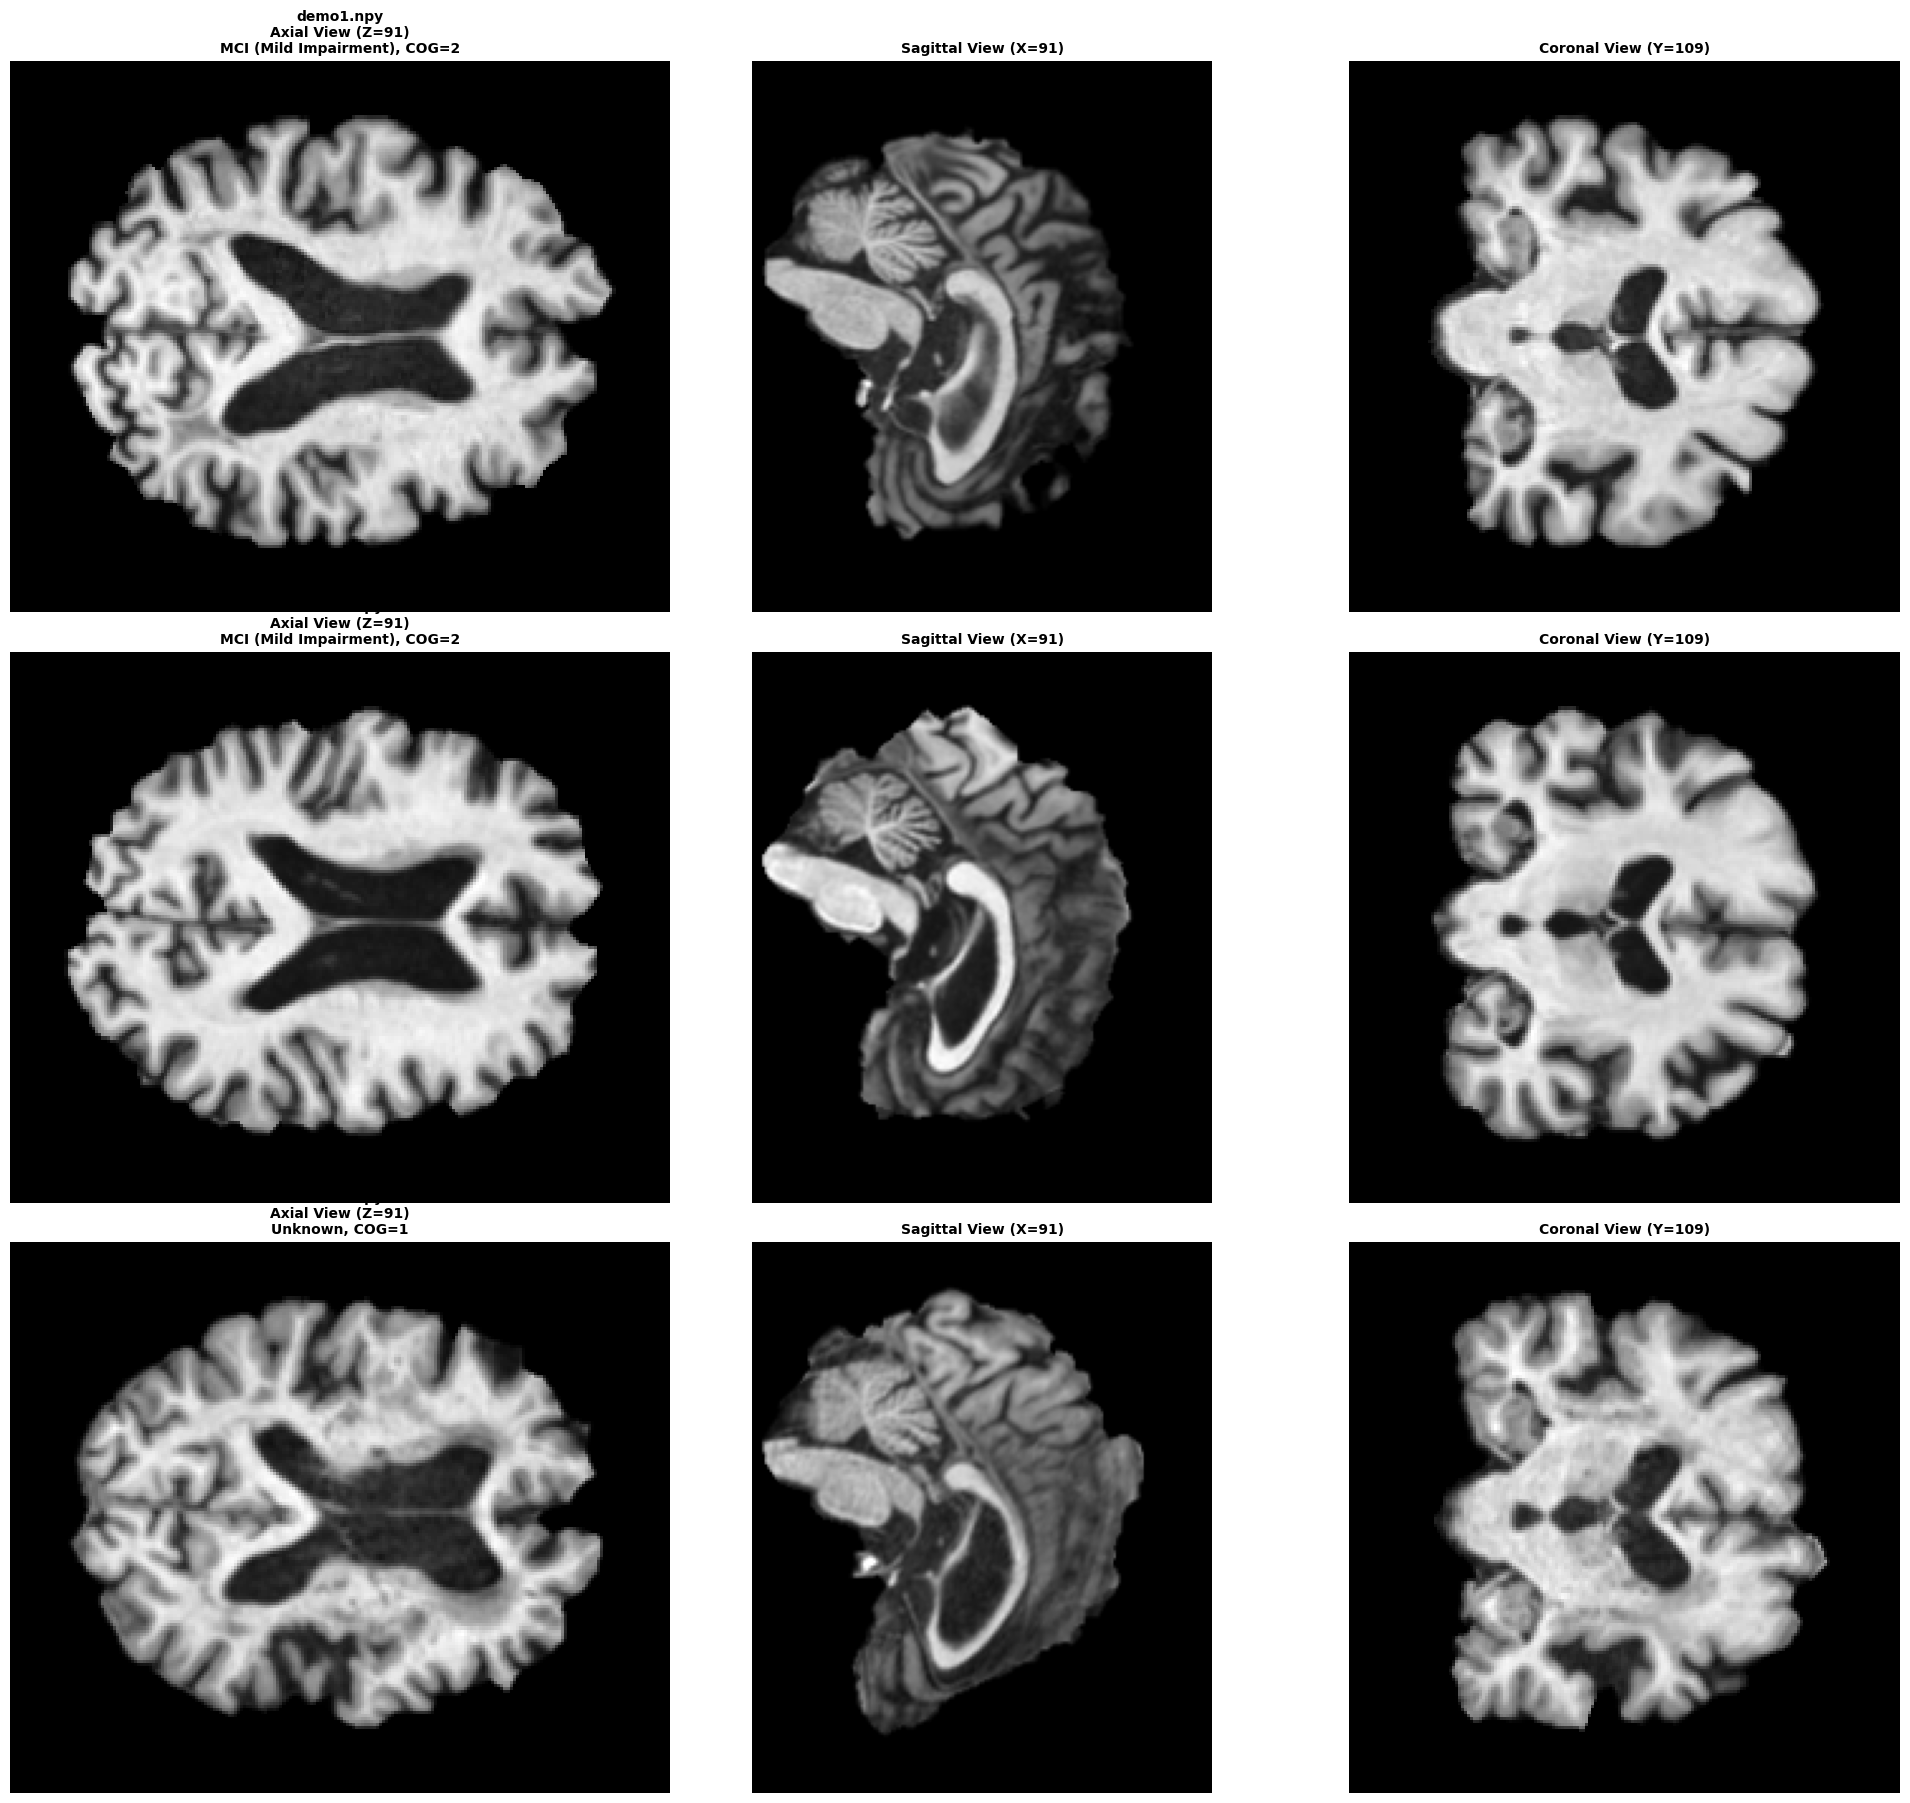


📊 SUMMARY REPORT

🧠 demo1.npy
   ──────────────────────────────────────────────────
   📐 MRI Shape: (182, 218, 182)
   📊 Voxel Count: 7,221,032 voxels
   💾 Memory Size: 27.55 MB
   🟡 Diagnosis: MCI (Mild Impairment)
   🧮 Cognitive Score: 2/3
   💡 Intensity Stats:
      • Mean: 1.00
      • Std: 1.92
      • Non-zero voxels: 1,861,214 (25.8%)

🧠 demo2.npy
   ──────────────────────────────────────────────────
   📐 MRI Shape: (182, 218, 182)
   📊 Voxel Count: 7,221,032 voxels
   💾 Memory Size: 27.55 MB
   🟡 Diagnosis: MCI (Mild Impairment)
   🧮 Cognitive Score: 2/3
   💡 Intensity Stats:
      • Mean: 1.00
      • Std: 1.95
      • Non-zero voxels: 1,833,058 (25.4%)

🧠 demo3.npy
   ──────────────────────────────────────────────────
   📐 MRI Shape: (182, 218, 182)
   📊 Voxel Count: 7,221,032 voxels
   💾 Memory Size: 27.55 MB
   ⚪ Diagnosis: Unable to determine
   🧮 Cognitive Score: 1/3
   💡 Intensity Stats:
      • Mean: 1.00
      • Std: 1.87
      • Non-zero voxels: 1,918,277 (26.6%)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from mpl_toolkits.axes_grid1 import ImageGrid
import os

print(" KIỂM TRA DỮ LIỆU DEMO\n")
print("="*60)

print("\n Các file trong thư mục demo/:")
!ls -lh demo/

print("\n Các file MRI trong demo/mri/:")
!ls -lh demo/mri/

print("\n" + "="*60)
print(" NỘI DUNG FILE demo/demo.csv (Metadata):")
print("="*60)

import pandas as pd
try:
    demo_meta = pd.read_csv('/content/ncomms2022/demo/demo.csv')
    print(demo_meta.to_string())
    print(f"\n Shape: {demo_meta.shape}")
    print(f" Columns: {list(demo_meta.columns)}")
except Exception as e:
    print(f" Không đọc được file: {e}")

print("\n" + "="*60)
print(" VISUALIZE CÁC MRI SCANS")
print("="*60)

mri_files = [f for f in os.listdir('demo/mri/') if f.endswith('.npy')]
print(f"\n Tìm thấy {len(mri_files)} file MRI: {mri_files}\n")


results = pd.read_csv('/content/ncomms2022/demo/demo.csv')

fig = plt.figure(figsize=(20, 6 * len(mri_files)))

ADD_labels = {
    0: "NC (Normal)",
    1: "MCI (Mild Impairment)",
    2: "AD (Alzheimer's)",
    3: "nADD (Other Dementia)"
}

for idx, filename in enumerate(sorted(mri_files)):
    filepath = os.path.join('demo/mri/', filename)

    try:
        mri_data = np.load(filepath)
        print(f" {filename}:")
        print(f"   Shape: {mri_data.shape}")
        print(f"   Data type: {mri_data.dtype}")
        print(f"   Value range: [{mri_data.min():.2f}, {mri_data.max():.2f}]")

        # Lấy kết quả dự đoán
        pred_row = results[results['filename'] == filename]
        if len(pred_row) > 0:
            add_pred = pred_row['ADD'].values[0]
            cog_pred = pred_row['COG'].values[0]

            if pd.notna(add_pred):
                add_label = ADD_labels[int(add_pred)]
            else:
                add_label = "Unknown"

            print(f"  Prediction: {add_label}, COG Score: {cog_pred}")
        print()

        # Visualize 3 mặt cắt: axial, sagittal, coronal
        # Lấy middle slices
        if len(mri_data.shape) == 3:
            mid_x, mid_y, mid_z = [s // 2 for s in mri_data.shape]

            # Axial (horizontal)
            ax1 = plt.subplot(len(mri_files), 3, idx * 3 + 1)
            plt.imshow(mri_data[:, :, mid_z], cmap='gray')
            plt.title(f'{filename}\nAxial View (Z={mid_z})\n{add_label}, COG={cog_pred}',
                     fontsize=10, fontweight='bold')
            plt.axis('off')

            # Sagittal (side)
            ax2 = plt.subplot(len(mri_files), 3, idx * 3 + 2)
            plt.imshow(mri_data[mid_x, :, :], cmap='gray')
            plt.title(f'Sagittal View (X={mid_x})', fontsize=10, fontweight='bold')
            plt.axis('off')

            # Coronal (front)
            ax3 = plt.subplot(len(mri_files), 3, idx * 3 + 3)
            plt.imshow(mri_data[:, mid_y, :], cmap='gray')
            plt.title(f'Coronal View (Y={mid_y})', fontsize=10, fontweight='bold')
            plt.axis('off')

    except Exception as e:
        print(f" Lỗi khi đọc {filename}: {e}\n")

plt.tight_layout()
plt.savefig('demo/mri_visualization.png', dpi=150, bbox_inches='tight')
print("\n Đã lưu visualization vào: demo/mri_visualization.png")
plt.show()


print("\n" + "="*60)
print(" SUMMARY REPORT")
print("="*60)

for idx, row in results.iterrows():
    filename = row['filename']
    filepath = os.path.join('demo/mri/', filename)

    if os.path.exists(filepath):
        mri_data = np.load(filepath)

        print(f"\n {filename}")
        print("   " + "─"*50)
        print(f"    MRI Shape: {mri_data.shape}")
        print(f"    Voxel Count: {np.prod(mri_data.shape):,} voxels")
        print(f"    Memory Size: {mri_data.nbytes / 1024 / 1024:.2f} MB")

        if pd.notna(row['ADD']):
            add_class = int(row['ADD'])
            status = [add_class]
            print(f"   {status} Diagnosis: {ADD_labels[add_class]}")
        else:
            print(f"    Diagnosis: Unable to determine")

        print(f"    Cognitive Score: {row['COG']}/3")

        # Phân tích intensity
        print(f"    Intensity Stats:")
        print(f"       Mean: {mri_data.mean():.2f}")
        print(f"       Std: {mri_data.std():.2f}")
        print(f"       Non-zero voxels: {np.count_nonzero(mri_data):,} ({np.count_nonzero(mri_data)/mri_data.size*100:.1f}%)")

print("\n" + "="*60)